In [1]:
## IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
import networkx as nx
from sklearn.neighbors import BallTree
import os
import folium
from folium.plugins import HeatMap

import sys
sys.path.append('../src')
from functions import (percentile_rank,
                       haversine,
                       ais_gap_analysis,
                       detect_sts_events,
                       route_irregularity_analysis,
                       name_change_analysis,
                       compute_vessel_risk,
                       run_anomaly_detection
)


In [2]:
## LOAD AND SAMPLE DATA

df0 = pd.read_csv("../data/raw/AIS_2018_09_30.csv")

row_num = 1000000
df0.head(row_num).to_csv(f"../data/processed/ais_sample{row_num}.csv", index=False)


In [3]:
## PREPROCESSING

filepath = f'../data/processed/ais_sample{row_num}.csv'
filepath1 = "../data/raw/AIS_2018_09_30.csv"
df = pd.read_csv(filepath1)

df["BaseDateTime"] = pd.to_datetime(df["BaseDateTime"])

# Remove duplicate pings (same vessel, same timestamp) — corrupt time deltas otherwise
df = df.drop_duplicates(subset=["MMSI", "BaseDateTime"])

# Sanity-check coordinates: drop null-island (0,0) and out-of-range values
df = df[(df["LAT"].between(-90, 90)) & (df["LON"].between(-180, 180))]
df = df[~((df["LAT"] == 0) & (df["LON"] == 0))]

# Drop physically impossible speeds (AIS spoofing / data error)
if "SOG" in df.columns:
    df = df[df["SOG"] <= 50]

df = df.sort_values(["MMSI", "BaseDateTime"])

# Ping count per vessel
ping_counts = df.groupby("MMSI").size().rename("ping_count")

print(f"Rows after cleaning: {len(df):,}")
print(f"Unique vessels: {df['MMSI'].nunique():,}")


Rows after cleaning: 7,867,643
Unique vessels: 16,525


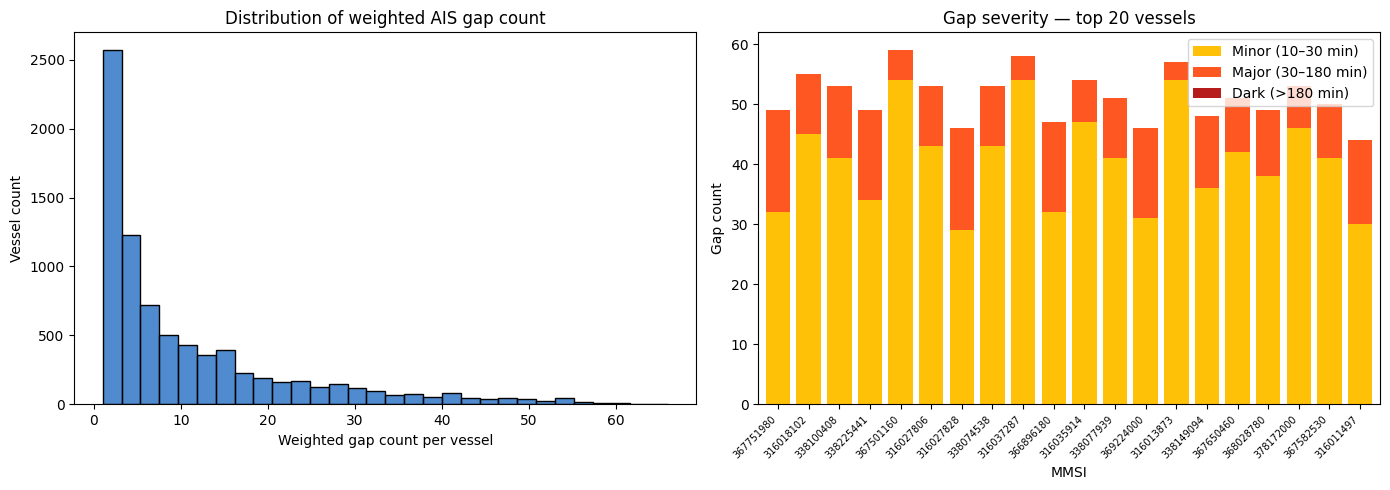

In [4]:
## AIS GAP ANALYSIS

gap_summary = ais_gap_analysis(df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of total weighted gap count (vessels with at least one gap)
has_gaps = gap_summary[gap_summary["gap_count"] > 0] 
sns.histplot(has_gaps["gap_count"], bins=30, ax=axes[0], color="#1565C0")
axes[0].set_title("Distribution of weighted AIS gap count")
axes[0].set_xlabel("Weighted gap count per vessel")
axes[0].set_ylabel("Vessel count")

# Stacked bar: minor / major / dark gaps for top 20 vessels by gap count
top_gap = gap_summary.nlargest(20, "gap_count")[["minor_gaps", "major_gaps", "dark_gaps"]]
top_gap.plot(
    kind="bar", stacked=True,
    color=["#FFC107", "#FF5722", "#B71C1C"],
    ax=axes[1], width=0.8
)
axes[1].set_title("Gap severity — top 20 vessels")
axes[1].set_xlabel("MMSI")
axes[1].set_ylabel("Gap count")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right", fontsize=7)
axes[1].legend(["Minor (10–30 min)", "Major (30–180 min)", "Dark (>180 min)"])

plt.tight_layout()
plt.show()


In [ ]:
## STS DETECTION

sts_df, sts_counts = detect_sts_events(df)

Starting STS detection
Total AIS points: 7867643
Unique vessels: 16525

Filtering low-speed AIS points (SOG < 2 knots)
Candidate AIS points: 5658490
Total space-time groups: 125364
Processing group 0/125364
Processing group 500/125364
Processing group 1000/125364
Processing group 1500/125364
Processing group 2000/125364
Processing group 2500/125364
Processing group 3000/125364
Processing group 3500/125364
Processing group 4000/125364
Processing group 4500/125364
Processing group 5000/125364
Processing group 5500/125364
Processing group 6000/125364
Processing group 6500/125364
Processing group 7000/125364
Processing group 7500/125364
Processing group 8000/125364
Processing group 8500/125364
Processing group 9000/125364
Processing group 9500/125364
Processing group 10000/125364
Processing group 10500/125364
Processing group 11000/125364
Processing group 11500/125364
Processing group 12000/125364
Processing group 12500/125364
Processing group 13000/125364
Processing group 13500/125364
Pro

In [ ]:
## ROUTE IRREGULARITY

ri = route_irregularity_analysis(df)
print(ri.describe())

count    1822.000000
mean        2.621462
std        52.335697
min         0.000000
25%         0.001543
50%         0.053983
75%         0.228744
max      1636.906728
Name: route_irregularity, dtype: float64


In [ ]:
## NAME CHANGE ANALYSIS

events, counts, multi_names = name_change_analysis(df)

print("Vessels with multiple names associated with the same MMSI:")
print(multi_names)


Vessels with multiple names associated with the same MMSI:
Series([], Name: VesselName, dtype: int64)


In [ ]:
## COMPUTING CONTINUOUS RISK SCORE

indicators = compute_vessel_risk(
    df,
    gap_summary=gap_summary,
)

# Attach ping count — vessels with few pings have unreliable scores
indicators = indicators.join(ping_counts)
indicators["low_coverage"] = indicators["ping_count"] < 10

print(indicators[["Risk_Score", "Flag_Count", "ping_count", "low_coverage"]]
      .sort_values("Risk_Score", ascending=False).head(10))


Starting STS detection
Total AIS points: 999271
Unique vessels: 1822

Filtering low-speed AIS points (SOG < 2 knots)
Candidate AIS points: 772910
Total space-time groups: 34498
Processing group 0/34498
Processing group 500/34498
Processing group 1000/34498
Processing group 1500/34498
Processing group 2000/34498
Processing group 2500/34498
Processing group 3000/34498
Processing group 3500/34498
Processing group 4000/34498
Processing group 4500/34498
Processing group 5000/34498
Processing group 5500/34498
Processing group 6000/34498
Processing group 6500/34498
Processing group 7000/34498
Processing group 7500/34498
Processing group 8000/34498
Processing group 8500/34498
Processing group 9000/34498
Processing group 9500/34498
Processing group 10000/34498
Processing group 10500/34498
Processing group 11000/34498
Processing group 11500/34498
Processing group 12000/34498
Processing group 12500/34498
Processing group 13000/34498
Processing group 13500/34498
Processing group 14000/34498
Proces

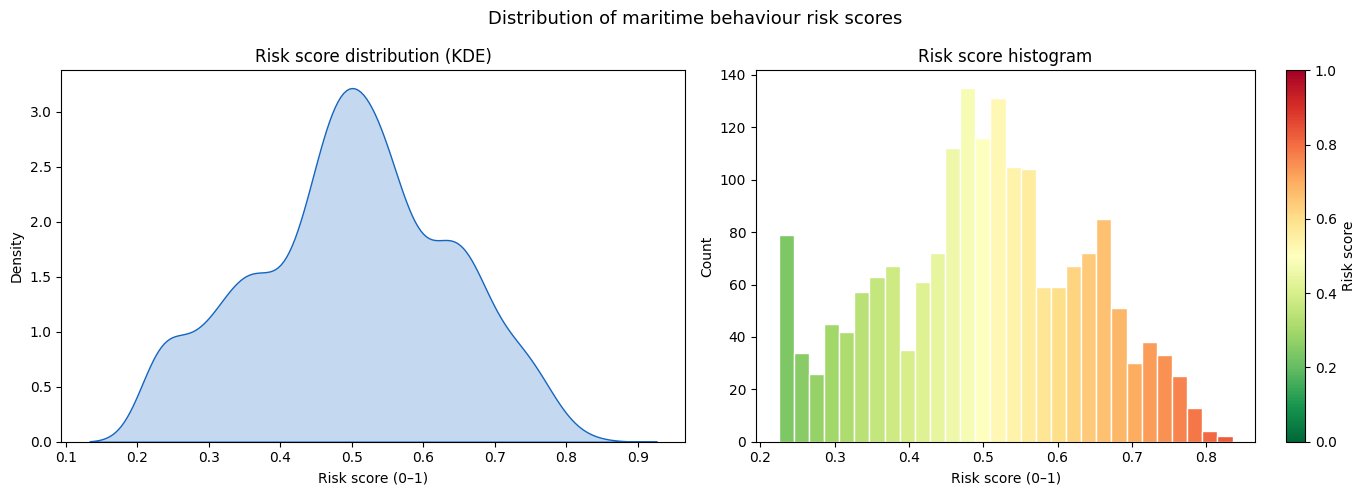

In [ ]:
## PLOTTING - RISK SCORE DISTRIBUTION

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE plot
sns.kdeplot(indicators["Risk_Score"], fill=True, color="#1565C0", ax=axes[0])
axes[0].set_title("Risk score distribution (KDE)")
axes[0].set_xlabel("Risk score (0–1)")
axes[0].set_ylabel("Density")

# Histogram with continuous colourmap
n, bins, patches = axes[1].hist(indicators["Risk_Score"], bins=30, edgecolor="white")
norm = mcolors.Normalize(vmin=0, vmax=1)
cmap = cm.RdYlGn_r
for patch, left in zip(patches, bins[:-1]):
    patch.set_facecolor(cmap(norm(left + (bins[1] - bins[0]) / 2)))
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=axes[1], label="Risk score")
axes[1].set_title("Risk score histogram")
axes[1].set_xlabel("Risk score (0–1)")
axes[1].set_ylabel("Count")

plt.suptitle("Distribution of maritime behaviour risk scores", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
## HIGH V LOW RISK VESSEL COMPARISON

threshold_high = indicators["Risk_Score"].quantile(0.90)
threshold_low  = indicators["Risk_Score"].quantile(0.10)

high_risk = indicators[indicators["Risk_Score"] >= threshold_high] 
low_risk  = indicators[indicators["Risk_Score"] <= threshold_low]

print(f"High risk vessels (top 10%):    {len(high_risk)}") 
print(f"Low risk vessels  (bottom 10%): {len(low_risk)}")
print("\nHigh risk avg:")
print(high_risk[["AIS_Gap_Count", "STS_Count", "Route_Irregularity",
                 "Name_Change_Count", "Risk_Score"]].mean().round(3))
print("\nLow risk avg:")
print(low_risk[["AIS_Gap_Count", "STS_Count", "Route_Irregularity",
                "Name_Change_Count", "Risk_Score"]].mean().round(3))


High risk vessels (top 10%):    183
Low risk vessels  (bottom 10%): 183

High risk avg:
AIS_Gap_Count            13.645
STS_Count             12049.098
Route_Irregularity        1.039
Name_Change_Count         0.000
Risk_Score                0.728
dtype: float64

Low risk avg:
AIS_Gap_Count         0.022
STS_Count             0.005
Route_Irregularity    0.001
Name_Change_Count     0.000
Risk_Score            0.257
dtype: float64


In [ ]:
## TOP VESSEL SELECTION

top_vessel = indicators.sort_values("Risk_Score", ascending=False).index[0]
vessel_df  = df[df["MMSI"] == top_vessel].copy()
print(f"Top risk vessel MMSI: {top_vessel}")


Top risk vessel MMSI: 367165265


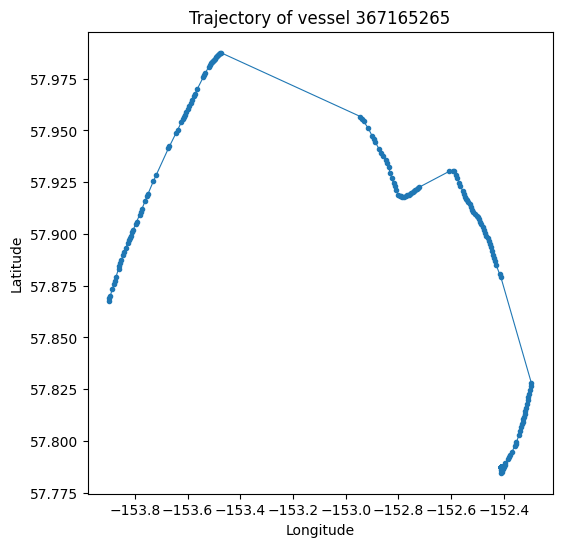

In [ ]:
## TRAJECTORY OF HIGHEST RISK VESSEL


plt.figure(figsize=(6, 6))
plt.plot(vessel_df["LON"], vessel_df["LAT"], marker="o", markersize=3, linewidth=0.8)
plt.title(f"Trajectory of vessel {top_vessel}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


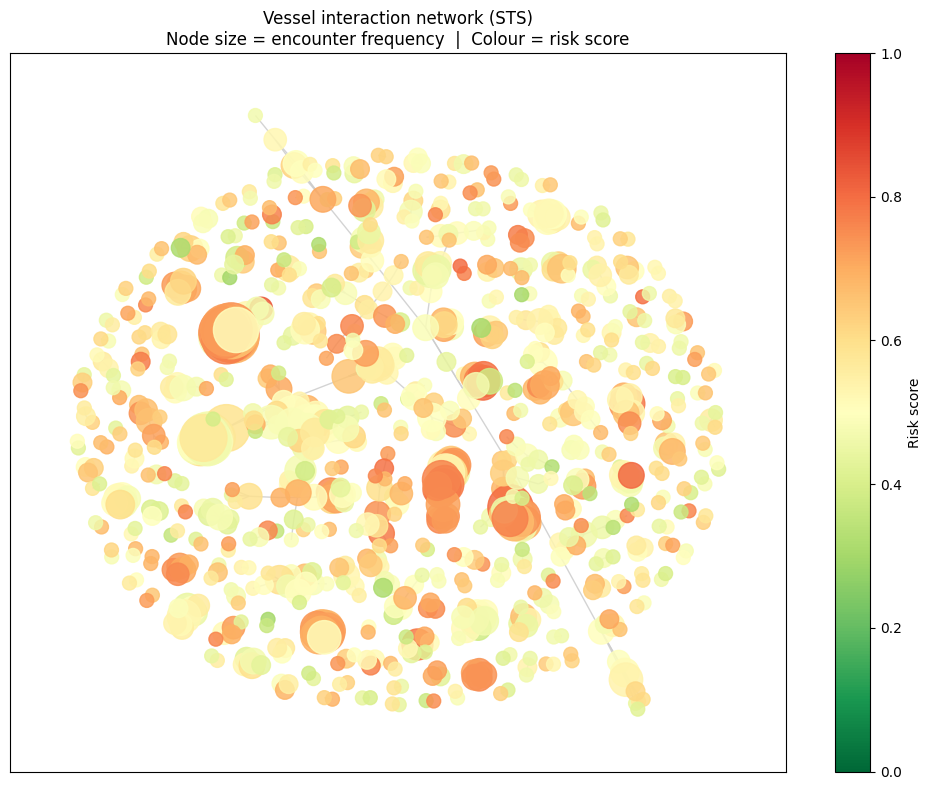

In [ ]:
## STS VESSEL INTERACTION NETWORK


G = nx.Graph()
for _, row in sts_df.iterrows():
    G.add_edge(row["MMSI1"], row["MMSI2"])

pos = nx.spring_layout(G, seed=42)

node_risk   = [indicators.loc[n, "Risk_Score"] if n in indicators.index else 0
               for n in G.nodes()]
node_degree = [G.degree(n) for n in G.nodes()]
node_sizes  = [d * 80 + 20 for d in node_degree]

cmap = cm.RdYlGn_r
norm = mcolors.Normalize(vmin=0, vmax=1)

fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx(
    G, pos,
    node_size=node_sizes,
    node_color=node_risk,
    cmap=cmap,
    vmin=0, vmax=1,
    edge_color="#cccccc",
    alpha=0.85,
    with_labels=False,
    ax=ax
)
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Risk score")
ax.set_title("Vessel interaction network (STS)\nNode size = encounter frequency  |  Colour = risk score")
plt.tight_layout()
plt.show()


In [ ]:
## PRIORITY RANKING

indicators["priority"] = (
    indicators["Risk_Score"] * 0.6 +
    indicators["anomaly_score"].clip(lower=0) * 0.4
)

print("Top 10 priority vessels:")
print(
    indicators.sort_values("priority", ascending=False)
    [["Risk_Score", "anomaly_score", "is_anomalous", "Flag_Count", "priority"]]
    .head(10).round(3)
)


Top 10 priority vessels:
           Risk_Score  anomaly_score  is_anomalous  Flag_Count  priority
367112630       0.807              1         False           2     0.884
563759000       0.800              1         False           2     0.880
368021936       0.790              1         False           2     0.874
366900190       0.790              1         False           2     0.874
941201932       0.782              1         False           2     0.869
366843020       0.782              1         False           2     0.869
941001073       0.777              1         False           2     0.866
941201975       0.777              1         False           2     0.866
538071296       0.777              1         False           2     0.866
941206432       0.772              1         False           2     0.863


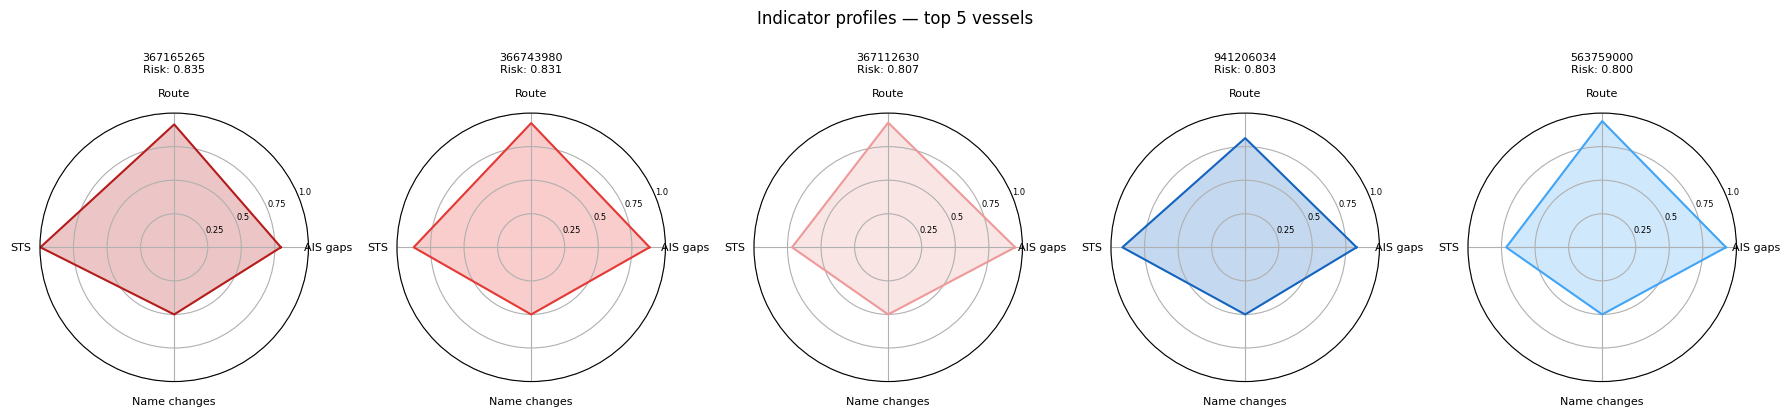

In [ ]:
## RADAR CHART 


from matplotlib.patches import FancyArrowPatch

features      = ["gap_score", "route_score", "sts_score", "name_score"]
feature_labels = ["AIS gaps", "Route", "STS", "Name changes"]
N = len(features)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

top5 = indicators.sort_values("Risk_Score", ascending=False).head(5)

fig, axes = plt.subplots(1, 5, figsize=(18, 4),
                         subplot_kw=dict(polar=True))

colors = ["#B71C1C", "#E53935", "#EF9A9A", "#1565C0", "#42A5F5"]

for ax, (mmsi, row), color in zip(axes, top5.iterrows(), colors):
    vals = [row[f] for f in features] + [row[features[0]]]
    ax.plot(angles, vals, color=color, linewidth=1.5)
    ax.fill(angles, vals, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feature_labels, size=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.5", "0.75", "1.0"], size=6)
    ax.set_title(f"{mmsi}\nRisk: {row['Risk_Score']:.3f}",
                 size=8, pad=12)

plt.suptitle("Indicator profiles — top 5 vessels", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


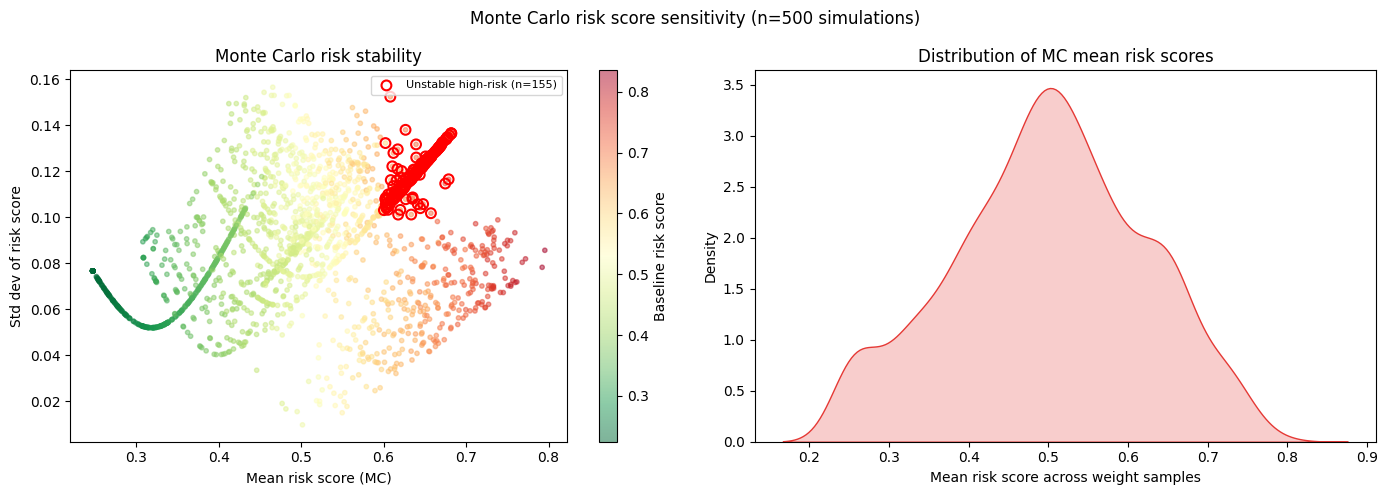

In [ ]:
## MONTE CARLO WEIGHT SENSITIVITY

def monte_carlo_risk(indicators, n_sim=500):
    """
    Stress-test the risk score by sampling random weight combinations.
    Vessels with high mc_mean are robustly risky regardless of weighting assumptions.
    Vessels with high mc_std have scores that are sensitive to weighting — treat with caution.
    """
    base_features = ["gap_score", "route_score", "sts_score", "name_score"]
    results = []
    for _ in range(n_sim):
        w = np.random.dirichlet(np.ones(len(base_features)))
        risk = sum(w[i] * indicators[base_features[i]] for i in range(len(base_features)))
        results.append(risk)
    mc_matrix = np.vstack(results)
    indicators = indicators.copy()
    indicators["mc_mean"] = mc_matrix.mean(axis=0)
    indicators["mc_std"]  = mc_matrix.std(axis=0)
    return indicators, mc_matrix


indicators, mc_matrix = monte_carlo_risk(indicators)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(
    indicators["mc_mean"], indicators["mc_std"],
    s=10, alpha=0.5,
    c=indicators["Risk_Score"], cmap="RdYlGn_r"
)
plt.colorbar(sc, ax=axes[0], label="Baseline risk score")

# Highlight unstable high-risk vessels
unstable = indicators[(indicators["mc_mean"] > 0.6) & (indicators["mc_std"] > 0.1)]
axes[0].scatter(unstable["mc_mean"], unstable["mc_std"],
                s=50, edgecolors="red", facecolors="none",
                linewidths=1.5, label=f"Unstable high-risk (n={len(unstable)})")
axes[0].legend(fontsize=8)
axes[0].set_xlabel("Mean risk score (MC)")
axes[0].set_ylabel("Std dev of risk score")
axes[0].set_title("Monte Carlo risk stability")

sns.kdeplot(indicators["mc_mean"], fill=True, ax=axes[1], color="#E53935")
axes[1].set_xlabel("Mean risk score across weight samples")
axes[1].set_title("Distribution of MC mean risk scores")

plt.suptitle("Monte Carlo risk score sensitivity (n=500 simulations)", fontsize=12)
plt.tight_layout()
plt.show()





mc_mean — the average risk score across all 500 simulations. A vessel with a high mean is consistently risky regardless of how you weight the indicators.
mc_std — the standard deviation of those 500 scores. A vessel with a low std has a stable score that doesn't change much with the weights. A vessel with a high std has a score that is very sensitive to weighting assumptions.

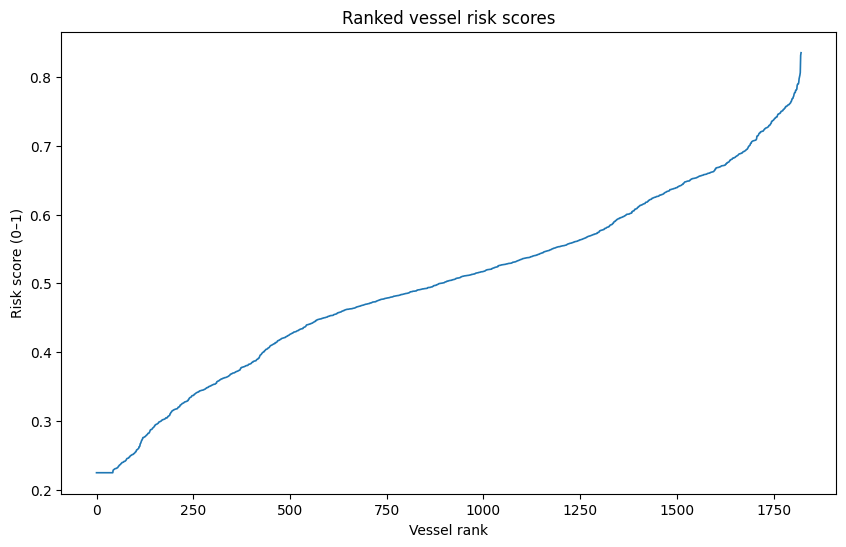

In [ ]:
## RANKED VESSEL RISK SCORES 

sorted_scores = indicators["Risk_Score"].sort_values()

plt.figure(figsize=(10, 6))
plt.plot(sorted_scores.values, linewidth=1.2)
plt.title("Ranked vessel risk scores")
plt.xlabel("Vessel rank")
plt.ylabel("Risk score (0–1)")
plt.show()


## 24 · Interactive map

In [ ]:
# [ORIGINAL]
import folium
m = folium.Map(
    location=[df["LAT"].mean(), df["LON"].mean()],
    zoom_start=2,
    tiles="CartoDB positron"
)


In [ ]:
# [ORIGINAL] vessel tracks
for mmsi, vessel in df.groupby("MMSI"):
    coords = list(zip(vessel["LAT"], vessel["LON"]))
    if len(coords) > 2:
        folium.PolyLine(coords, color="blue", weight=1, opacity=0.4).add_to(m)


In [ ]:
# [MODIFIED] 3-colour risk gradient; richer popup with flag breakdown; HTML legend;
#            STS heatmap layer replacing raw purple markers

for mmsi, row in indicators.iterrows():
    vessel_data = df[df["MMSI"] == mmsi]
    if vessel_data.empty:
        continue
    last_point = vessel_data.iloc[-1]
    risk = row["Risk_Score"]

    color = "red" if risk > 0.7 else ("orange" if risk > 0.4 else "green")

    fired_flags = []
    if row["flag_gap"]:   fired_flags.append("AIS gap")
    if row["flag_route"]: fired_flags.append("Route irregularity")
    if row["flag_sts"]:   fired_flags.append("STS")
    if row["flag_name"]:  fired_flags.append("Name change")
    flag_str = ", ".join(fired_flags) if fired_flags else "None"

    popup_html = f"""
        <b>MMSI:</b> {mmsi}<br>
        <b>Risk score:</b> {risk:.3f}<br>
        <b>Flags fired:</b> {flag_str}<br>
        <b>STS encounters:</b> {int(row['STS_Count'])}<br>
        <b>AIS gaps (weighted):</b> {int(row['AIS_Gap_Count'])}
    """

    folium.CircleMarker(
        location=[last_point["LAT"], last_point["LON"]],
        radius=3 + risk * 10,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=220)
    ).add_to(m)

# STS heatmap layer
if len(sts_df) > 0:
    sts_heat_points = []
    for _, row in sts_df.iterrows():
        v1_data = df[df["MMSI"] == row["MMSI1"]]
        v2_data = df[df["MMSI"] == row["MMSI2"]]
        if v1_data.empty or v2_data.empty:
            continue
        v1, v2 = v1_data.iloc[-1], v2_data.iloc[-1]
        sts_heat_points.append([
            (v1["LAT"] + v2["LAT"]) / 2,
            (v1["LON"] + v2["LON"]) / 2
        ])
    if sts_heat_points:
        HeatMap(sts_heat_points, name="STS hotspots",
                radius=15, blur=10, min_opacity=0.4).add_to(m)

# HTML legend
legend_html = """
<div style="position:fixed;bottom:30px;left:30px;z-index:1000;
            background:white;padding:10px 14px;border-radius:6px;
            border:1px solid #ccc;font-size:12px;line-height:1.8">
  <b>Vessel risk</b><br>
  <span style='color:red'>&#9679;</span> High (&gt;0.7)<br>
  <span style='color:orange'>&#9679;</span> Medium (0.4–0.7)<br>
  <span style='color:green'>&#9679;</span> Low (&lt;0.4)<br>
  <b>Heatmap:</b> STS encounter density
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
folium.LayerControl().add_to(m)

m


KeyboardInterrupt: 

In [ ]:
## CONCLUSIONS

# [MODIFIED] added vessel name lookup alongside MMSI for readability
top5 = indicators.sort_values("Risk_Score", ascending=False).head(5)

# Most frequent name per MMSI — guards against occasional data inconsistencies
vessel_names = (
    df.groupby("MMSI")["VesselName"]
    .agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else "Unknown")
)

print("=" * 60)
print("VESSEL INTELLIGENCE SUMMARIES")
print("=" * 60)

for mmsi, row in top5.iterrows():
    fired = []
    if row["flag_gap"]:
        fired.append(
            f"AIS gap count in top 20% of all vessels "
            f"(weighted score: {int(row['AIS_Gap_Count'])})")
    if row["flag_sts"]:
        fired.append(
            f"STS encounter count in top 20% "
            f"({int(row['STS_Count'])} encounter(s))")
    if row["flag_route"]:
        fired.append(
            f"Route irregularity in top 20% "
            f"(step-distance std dev: {row['Route_Irregularity']:.2f} km)")
    if row["flag_name"]:
        fired.append(
            f"Name changes detected "
            f"({int(row['Name_Change_Count'])} change(s))")

    anomaly_label = "flagged as anomalous" if row["is_anomalous"] else "not flagged as anomalous"
    coverage_note = " [LOW COVERAGE — treat with caution]" if row["low_coverage"] else ""
    vessel_name   = vessel_names.get(mmsi, "Unknown")

    print(f"\nMMSI {mmsi}  |  {vessel_name}{coverage_note}")
    print(f"  Risk score  : {row['Risk_Score']:.3f}  |  Flags fired: {int(row['Flag_Count'])}/4")
    print(f"  Anomaly     : {anomaly_label} (score: {row['anomaly_score']:.3f})")
    print(f"  Priority    : {row['priority']:.3f}")
    if fired:
        print("  Reasons:")
        for f in fired:
            print(f"    · {f}")
    else:
        print("  Reasons: no individual flags fired (elevated composite score)")

print("\n" + "=" * 60)


VESSEL INTELLIGENCE SUMMARIES

MMSI 367165265  |  Unknown
  Risk score  : 0.835  |  Flags fired: 2/4
  Anomaly     : flagged as anomalous (score: -1.000)
  Priority    : 0.501
  Reasons:
    · STS encounter count in top 20% (98044 encounter(s))
    · Route irregularity in top 20% (step-distance std dev: 1.15 km)

MMSI 366743980  |  GOLD RUSH
  Risk score  : 0.831  |  Flags fired: 3/4
  Anomaly     : flagged as anomalous (score: -1.000)
  Priority    : 0.499
  Reasons:
    · AIS gap count in top 20% of all vessels (weighted score: 13)
    · STS encounter count in top 20% (8852 encounter(s))
    · Route irregularity in top 20% (step-distance std dev: 1.44 km)

MMSI 367112630  |  ABBIE & HOLLY
  Risk score  : 0.807  |  Flags fired: 2/4
  Anomaly     : not flagged as anomalous (score: 1.000)
  Priority    : 0.884
  Reasons:
    · AIS gap count in top 20% of all vessels (weighted score: 22)
    · Route irregularity in top 20% (step-distance std dev: 1.57 km)

MMSI 941206034  |  Unknown
  Ri